In [ ]:
!pip -q install textstat emoji gdown nltk==3.8.1 transformers datasets scikit-learn scipy gradio imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 62.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
textblob 0.19.0 requires nltk>=3.9, but you have nltk 3.8.1 which is incompatible.


In [ ]:
import os, io, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textstat, emoji, gdown, joblib, nltk, torch, requests

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
from scipy.special import softmax
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
for r in ["punkt","punkt_tab","stopwords","averaged_perceptron_tagger","averaged_perceptron_tagger_eng"]:
    try: nltk.download(r, quiet=True)
    except: pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cpu": print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
# All constants and helpers defined once here — used throughout and in Gradio

METADATA_FEATURES = [
    "review_length", "burstiness", "hedging_ratio", "modal_ratio",
    "adj_density", "punct_diversity", "flesch_ease", "ari_score",
]

HEDGING_WORDS = frozenset({"maybe","perhaps","possibly","might","could","seems","appears","likely","unlikely"})
MODAL_VERBS   = frozenset({"would","could","should","might","may","must"})
STOP_WORDS    = set(stopwords.words("english"))

def get_sentiment_rating(text):
    if not text or len(str(text).strip()) == 0: return 3.0
    t = str(text).lower()
    pos = ["good","great","excellent","awesome","amazing","love","best","perfect","wonderful","fantastic",
           "superb","outstanding","recommend","quality","satisfied","happy","impressed","beautiful","nice",
           "worth","helpful","useful","fast","quickly","safe","fine","working","trust","wow","thanks","thanx",
           "supiri","supiriyak","honda","hodai","hoday","hodata","lassana","niyamai","patta","elakiri","ela",
           "ikmanata","ikmanatama","watinawa","jaya","maru"]
    neg = ["bad","terrible","awful","horrible","poor","worst","hate","disappointing","disappointed","useless",
           "waste","broken","defective","damaged","issue","problem","not good","not working","dont buy",
           "avoid","refund","fake","scam","late","narakai","naraka","aula","aul","cha","chaa","padu",
           "boruwak","boru","kadila","wada na","wada ne"]
    p = sum(1 for w in pos if w in t)
    n = sum(1 for w in neg if w in t)
    if p > n: return 5.0 if p >= 3 else 4.0
    elif n > p: return 1.0 if n >= 3 else 2.0
    return 4.0 if len(t.split()) > 50 else 3.0

def normalize_rating(r):
    if isinstance(r, str) and "out of" in r: return float(r.split()[0])
    try: return float(r)
    except: return 3.0

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return re.sub(r"\s+", " ", text).strip()

def remove_stopwords(text):
    return " ".join([w for w in word_tokenize(str(text)) if w not in STOP_WORDS])

def extract_metadata(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series({f: 0.0 for f in METADATA_FEATURES})
    sents  = sent_tokenize(text)
    tokens = word_tokenize(text.lower())
    words  = [w for w in tokens if w.isalpha()]
    wc     = len(words)
    slens  = [len(word_tokenize(s)) for s in sents if s.strip()]
    burstiness = float(np.std(slens)) if len(slens) > 1 else 0.0
    hedging    = sum(1 for w in words if w in HEDGING_WORDS) / (wc + 1)
    modal      = sum(1 for w in words if w in MODAL_VERBS)   / (wc + 1)
    tagged     = nltk.pos_tag(words) if wc else []
    adj_d      = sum(1 for _, t in tagged if t in ("JJ","JJR","JJS")) / (wc + 1)
    punct      = [c for c in text if c in ".:,!?;:"]
    punct_div  = len(set(punct)) / (len(punct) + 1)
    try:    flesch = textstat.flesch_reading_ease(text)
    except: flesch = 0.0
    try:    ari    = textstat.automated_readability_index(text)
    except: ari    = 0.0
    return pd.Series({
        "review_length": len(text),   "burstiness": burstiness,
        "hedging_ratio": hedging,     "modal_ratio": modal,
        "adj_density":   adj_d,       "punct_diversity": punct_div,
        "flesch_ease":   flesch,      "ari_score": ari,
    })

def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["AI","Human"], yticklabels=["AI","Human"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)

In [ ]:
# Download raw datasets from Google Drive
FILES = {
    "amazon.csv": "1hmwA31xoBZGcSSqQuyJ86OkFYQuym2Xg",
    "daraz.csv":  "1Ih_YxAGSBbAvEfUeYEei3Tg9_CajayLC",
    "ebay.csv":   "1m-f8j8wSWCU3dvXA6Rvko21NfdPhLsiB",
    "temu.csv":   "14jhVFToeqNYD0d-APN6AIxEHhhyln9TU",
    "ai_rev.csv": "18QrdzbdziQDnEBuaXH-b4i2cf60IkFap",
}
for name, fid in FILES.items():
    if not os.path.exists(name):
        gdown.download(f"https://drive.google.com/uc?id={fid}", name, quiet=False)

amazon = pd.read_csv("amazon.csv")
daraz  = pd.read_csv("daraz.csv")
ebay   = pd.read_csv("ebay.csv")
temu   = pd.read_csv("temu.csv")
ai_rev = pd.read_csv("ai_rev.csv")
for name, df in [("Amazon",amazon),("Daraz",daraz),("eBay",ebay),("Temu",temu),("AI",ai_rev)]:
    print(f"{name}: {df.shape}")

Downloading...
From: https://drive.google.com/uc?id=1hmwA31xoBZGcSSqQuyJ86OkFYQuym2Xg
To: /content/amazon.csv
100%|██████████| 2.49M/2.49M [00:00<00:00, 20.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ih_YxAGSBbAvEfUeYEei3Tg9_CajayLC
To: /content/daraz.csv
100%|██████████| 340k/340k [00:00<00:00, 3.93MB/s]
Downloading...
From: https://drive.google.com/uc?id=1m-f8j8wSWCU3dvXA6Rvko21NfdPhLsiB
To: /content/ebay.csv
100%|██████████| 353k/353k [00:00<00:00, 4.60MB/s]
Downloading...
From: https://drive.google.com/uc?id=14jhVFToeqNYD0d-APN6AIxEHhhyln9TU
To: /content/temu.csv
100%|██████████| 505k/505k [00:00<00:00, 6.00MB/s]
Downloading...
From: https://drive.google.com/uc?id=18QrdzbdziQDnEBuaXH-b4i2cf60IkFap
To: /content/ai_rev.csv
100%|██████████| 5.66M/5.66M [00:00<00:00, 24.4MB/s]


Amazon: (5086, 6)
Daraz: (3607, 5)
eBay: (2810, 3)
Temu: (4487, 4)
AI: (18614, 4)


In [ ]:
# Standardise columns, apply sentiment ratings where needed, and combine platforms
amazon = amazon.rename(columns={"a-profile-name":"review_name","a-icon-alt":"review_rating",
                                 "a-size-base 3":"review_txt","a-size-base 2":"review_date"})
daraz  = daraz.rename(columns={"title":"review_date","middle":"review_name","content":"review_txt"})
ebay   = ebay.rename(columns={"review-item-author":"review_name","review-item-date":"review_date",
                               "review-item-content":"review_txt"})
temu   = temu.rename(columns={"XTEkYdlM":"review_name","_1tSRIohB 2":"review_date","_2EO0yd2j":"review_txt"})

for df in [daraz, ebay, temu]:
    df["review_rating"] = df["review_txt"].apply(get_sentiment_rating)
for df, name in [(amazon,"Amazon"),(daraz,"Daraz"),(ebay,"Ebay"),(temu,"Temu")]:
    df["platform"] = name

COLS = ["review_name","review_date","review_txt","review_rating","platform"]
human = pd.concat([amazon[COLS], daraz[COLS], ebay[COLS], temu[COLS]], ignore_index=True)
human = human.dropna().drop_duplicates()
human = human[~human["review_txt"].str.contains("https://img.lazcdn.com", na=False)]
human["review_rating"] = human["review_rating"].apply(normalize_rating)

ai = ai_rev.dropna(subset=["review_txt"]).drop_duplicates(subset=["review_txt"]).copy()
ai["review_rating"] = ai["review_rating"].apply(normalize_rating)
p95 = int(human["review_txt"].str.len().quantile(0.95))
ai  = ai[ai["review_txt"].str.len() <= p95].copy()

print(f"Human: {len(human):,}  |  AI: {len(ai):,}  |  Length cap (95th pct): {p95}")

Human: 14,659  |  AI: 14,039  |  Length cap (95th pct): 611


In [ ]:
# Inject McAuley Amazon 2018 dataset to boost human-review diversity
try:
    url    = "https://jmcauley.ucsd.edu/data/amazon_v2/categoryFilesSmall/All_Beauty_5.json.gz"
    resp   = requests.get(url, verify=False, timeout=30)
    anchor = pd.read_json(io.BytesIO(resp.content), lines=True, compression="gzip")
    anchor = anchor.rename(columns={"reviewText":"review_txt","reviewerName":"review_name",
                                    "overall":"review_rating","reviewTime":"review_date"})
    anchor = anchor.dropna(subset=["review_txt"])
    anchor = anchor[anchor["review_txt"].str.len() >= 10].sample(n=min(4000,len(anchor)), random_state=42)
    anchor["platform"] = "McAuley"
    human  = pd.concat([human[COLS], anchor[COLS]], ignore_index=True)
    print("McAuley anchor added. Total human:", len(human))
except Exception as e:
    print("McAuley download skipped:", e)

McAuley anchor added. Total human: 18659


In [ ]:
# Extract cleaned text + 8 metadata features for both classes
print("Extracting human metadata (this takes a few minutes)...")
human["clean_review"] = human["review_txt"].apply(clean_text)
human = pd.concat([human.reset_index(drop=True),
                   human["review_txt"].apply(extract_metadata)], axis=1)
human["label"] = 1

print("Extracting AI metadata...")
ai["clean_review"] = ai["review_txt"].apply(clean_text)
ai = pd.concat([ai.reset_index(drop=True),
                ai["review_txt"].apply(extract_metadata)], axis=1)
ai["label"] = 0

FEAT_COLS = ["review_txt","clean_review"] + METADATA_FEATURES + ["label"]
dataset = pd.concat([human[FEAT_COLS], ai[FEAT_COLS]], ignore_index=True)
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nDataset shape:", dataset.shape)
print(dataset["label"].value_counts().rename({0:"AI",1:"Human"}))

Extracting human metadata (this takes a few minutes)...
Extracting AI metadata...

Dataset shape: (35579, 11)
label
Human    18659
AI       16920
Name: count, dtype: int64


In [ ]:
print("Individual Datasets:")
print(f"Amazon: {amazon.shape}")
print(f"Daraz: {daraz.shape}")
print(f"eBay: {ebay.shape}")
print(f"Temu: {temu.shape}")
print(f"AI Reviews: {ai_rev.shape}")

print("\nProcessed Datasets:")
print(f"Human: {human.shape}")
print(f"AI: {ai.shape}")

print("\nCombined Dataset:")
print(f"Final Dataset: {dataset.shape}")

Individual Datasets:
Amazon: (5086, 7)
Daraz: (3607, 7)
eBay: (2810, 5)
Temu: (4487, 6)
AI Reviews: (18614, 4)

Processed Datasets:
Human: (18659, 15)
AI: (16920, 14)

Combined Dataset:
Final Dataset: (35579, 11)


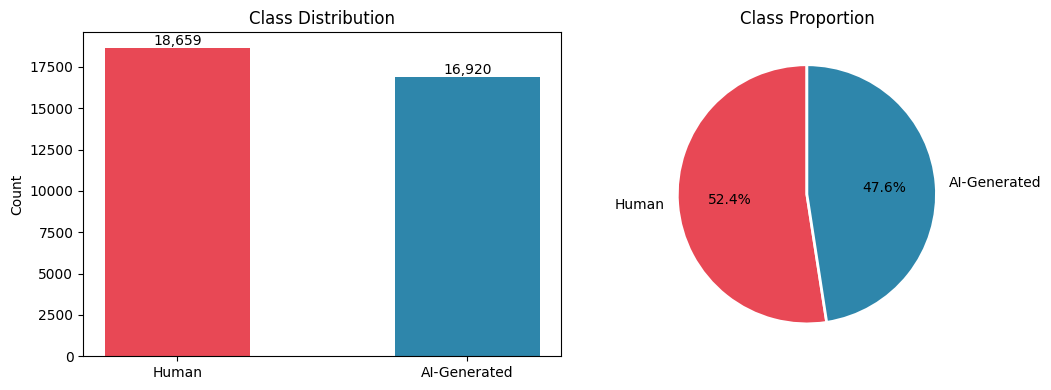

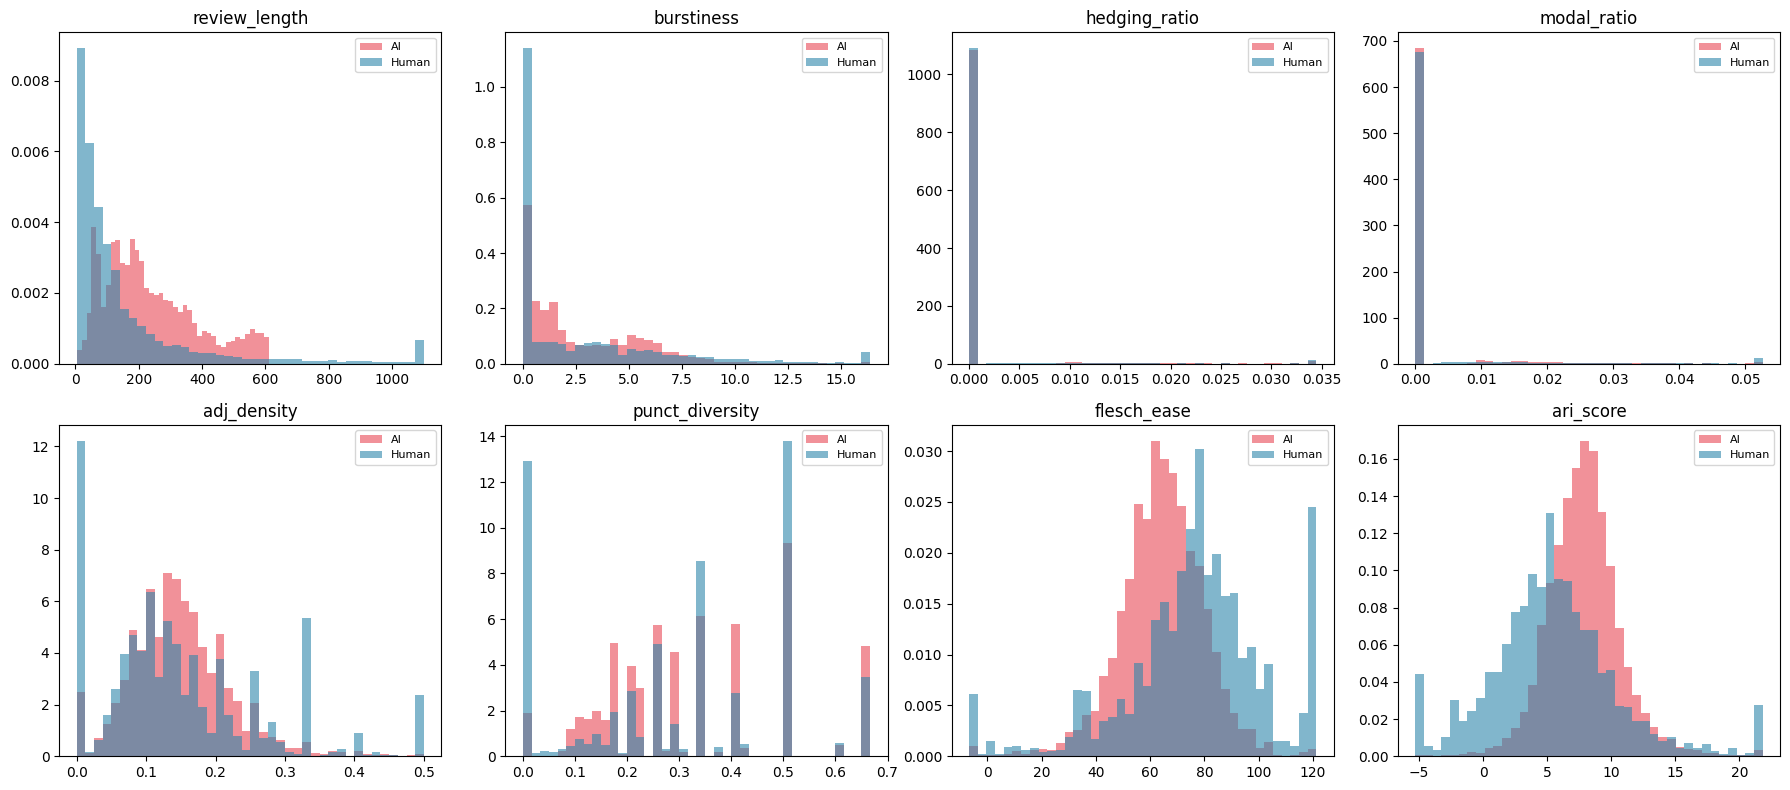

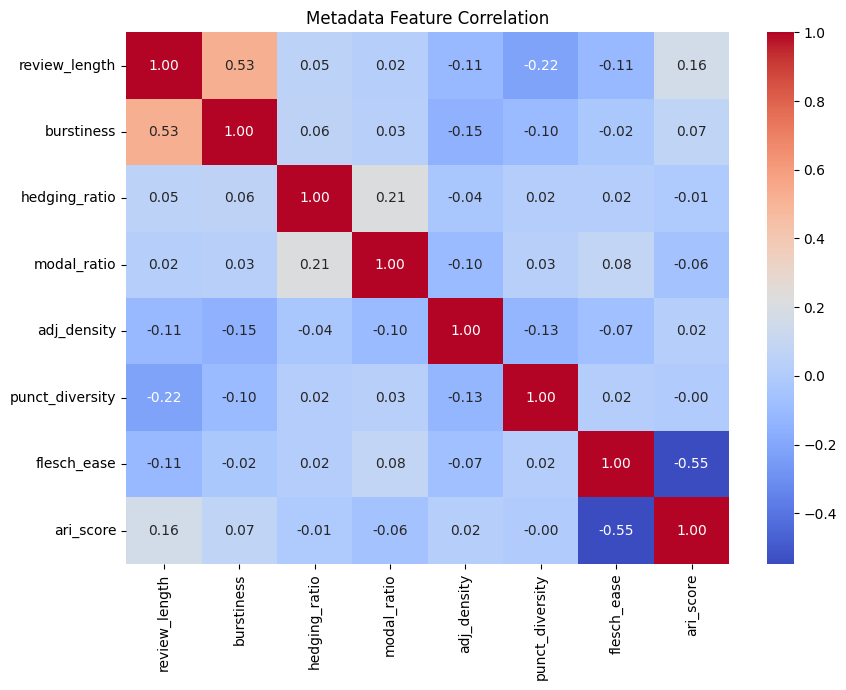

In [ ]:
# Class distribution overview
AI_COL = "#E84855"; HU_COL = "#2E86AB"
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = dataset["label"].value_counts().rename({0:"AI-Generated",1:"Human"})
bars = axes[0].bar(counts.index, counts.values, color=[AI_COL,HU_COL], width=0.5)
for b, v in zip(bars, counts.values): axes[0].text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom")
axes[0].set_title("Class Distribution"); axes[0].set_ylabel("Count")
axes[1].pie(counts.values, labels=counts.index, colors=[AI_COL,HU_COL],
            autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Class Proportion")
plt.tight_layout(); plt.show()

# Metadata feature distributions by class
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(METADATA_FEATURES):
    for lv, lname, color in [(0,"AI",AI_COL),(1,"Human",HU_COL)]:
        sub = dataset[dataset["label"]==lv][feat].clip(
            lower=dataset[feat].quantile(0.01), upper=dataset[feat].quantile(0.99))
        axes[i].hist(sub, bins=40, alpha=0.6, color=color, label=lname, density=True)
    axes[i].set_title(feat); axes[i].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Metadata correlation heatmap
corr = dataset[METADATA_FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Metadata Feature Correlation")
plt.tight_layout(); plt.show()

In [ ]:
# Train/test split, TF-IDF + metadata feature matrix, then SMOTE oversampling
X_raw = dataset["review_txt"]; y = dataset["label"]
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

clean_train = X_train_raw.apply(clean_text).apply(remove_stopwords)
clean_test  = X_test_raw.apply(clean_text).apply(remove_stopwords)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X_tr_tfidf = tfidf.fit_transform(clean_train)
X_te_tfidf = tfidf.transform(clean_test)

scaler     = StandardScaler()
X_tr_meta  = scaler.fit_transform(X_train_raw.apply(extract_metadata))
X_te_meta  = scaler.transform(X_test_raw.apply(extract_metadata))

X_train = hstack([X_tr_tfidf, csr_matrix(X_tr_meta)])
X_test  = hstack([X_te_tfidf, csr_matrix(X_te_meta)])

print("Before SMOTE:", dict(pd.Series(y_train).value_counts().rename({0:"AI",1:"Human"})))
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print("After SMOTE :", dict(pd.Series(y_train_sm).value_counts().rename({0:"AI",1:"Human"})))
print("Train shape:", X_train_sm.shape, " | Test shape:", X_test.shape)

Before SMOTE: {'Human': np.int64(14927), 'AI': np.int64(13536)}
After SMOTE : {'Human': np.int64(14927), 'AI': np.int64(14927)}
Train shape: (29854, 5008)  | Test shape: (7116, 5008)


In [ ]:
# Train ExtraTrees and RandomForest on SMOTE-balanced feature matrix
best_et = ExtraTreesClassifier(n_estimators=400, max_features="sqrt",
                                class_weight="balanced", random_state=42, n_jobs=-1)
best_rf = RandomForestClassifier(n_estimators=300, max_depth=40, max_features="sqrt",
                                  class_weight="balanced_subsample", bootstrap=True,
                                  random_state=42, n_jobs=-1)

print("Training ExtraTrees...")
best_et.fit(X_train_sm, y_train_sm)
et_preds = best_et.predict(X_test); et_proba = best_et.predict_proba(X_test)
print(classification_report(y_test, et_preds, target_names=["AI","Human"]))

print("Training RandomForest...")
best_rf.fit(X_train_sm, y_train_sm)
rf_preds = best_rf.predict(X_test); rf_proba = best_rf.predict_proba(X_test)
print(classification_report(y_test, rf_preds, target_names=["AI","Human"]))

Training ExtraTrees...
              precision    recall  f1-score   support

          AI       0.99      0.96      0.97      3384
       Human       0.96      0.99      0.98      3732

    accuracy                           0.98      7116
   macro avg       0.98      0.98      0.98      7116
weighted avg       0.98      0.98      0.98      7116

Training RandomForest...
              precision    recall  f1-score   support

          AI       0.99      0.90      0.94      3384
       Human       0.91      0.99      0.95      3732

    accuracy                           0.95      7116
   macro avg       0.95      0.94      0.95      7116
weighted avg       0.95      0.95      0.95      7116



In [ ]:
# 5-fold stratified cross-validation on SMOTE-balanced training data
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy","f1_weighted","precision_weighted","recall_weighted"]

for name, clf in [("ExtraTrees", best_et), ("RandomForest", best_rf)]:
    cv = cross_validate(clf, X_train_sm, y_train_sm, cv=skf, scoring=scoring, n_jobs=-1)
    print(f"\n{name} 5-Fold CV:")
    for m in scoring:
        s = cv[f"test_{m}"]
        print(f"  {m:<22}: {s.mean():.4f} \u00b1 {s.std():.4f}")


ExtraTrees 5-Fold CV:
  accuracy              : 0.9774 ± 0.0011
  f1_weighted           : 0.9774 ± 0.0011
  precision_weighted    : 0.9779 ± 0.0011
  recall_weighted       : 0.9774 ± 0.0011

RandomForest 5-Fold CV:
  accuracy              : 0.9467 ± 0.0014
  f1_weighted           : 0.9466 ± 0.0014
  precision_weighted    : 0.9506 ± 0.0013
  recall_weighted       : 0.9467 ± 0.0014


In [ ]:
bert_trained = False; tokenizer = None; bert_model = None
bert_preds = None; bert_proba_raw = None

if device.type != "cpu":
    from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification,
                               TrainingArguments, Trainer, EarlyStoppingCallback)
    from datasets import Dataset as HFDataset

    tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

    train_hf = HFDataset.from_pandas(
        pd.DataFrame({"text": X_train_raw.fillna('').values, "label": y_train.values})).map(tokenize, batched=True)
    test_hf  = HFDataset.from_pandas(
        pd.DataFrame({"text": X_test_raw.fillna('').values,  "label": y_test.values})).map(tokenize, batched=True)
    for ds in [train_hf, test_hf]:
        ds.set_format("torch", columns=["input_ids","attention_mask","label"])

    bert_model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2).to(device)

    args = TrainingArguments(
        output_dir="/content/distilbert_checkpoints",
        num_train_epochs=4, per_device_train_batch_size=32, per_device_eval_batch_size=32,
        gradient_accumulation_steps=4, warmup_ratio=0.1, weight_decay=0.01, learning_rate=1.5e-5,
        eval_strategy="epoch", save_strategy="epoch", load_best_model_at_end=True,
        metric_for_best_model="eval_loss", fp16=True, dataloader_num_workers=2, report_to="none")

    trainer = Trainer(model=bert_model, args=args, train_dataset=train_hf, eval_dataset=test_hf,
                      callbacks=[EarlyStoppingCallback(early_stopping_patience=1)])
    print("Training DistilBERT...")
    trainer.train()

    out            = trainer.predict(test_hf)
    bert_proba_raw = softmax(out.predictions, axis=1)
    bert_preds     = np.argmax(bert_proba_raw, axis=1)
    bert_trained   = True
    print(classification_report(y_test, bert_preds, target_names=["AI","Human"]))
else:
    print("No GPU detected — DistilBERT skipped. Ensemble will use ET + RF only.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/28463 [00:00<?, ? examples/s]

Map:   0%|          | 0/7116 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


              precision    recall  f1-score   support

          AI       0.99      0.99      0.99      3384
       Human       0.99      0.99      0.99      3732

    accuracy                           0.99      7116
   macro avg       0.99      0.99      0.99      7116
weighted avg       0.99      0.99      0.99      7116



In [ ]:
# Build soft-voting ensemble with F1-proportional weights
if bert_trained:
    et_f1 = f1_score(y_test, et_preds, average="weighted")
    rf_f1 = f1_score(y_test, rf_preds, average="weighted")
    b_f1  = f1_score(y_test, bert_preds, average="weighted")
    # Square F1 scores to amplify differences between models
    et_f1_sq = et_f1 ** 2
    rf_f1_sq = rf_f1 ** 2
    b_f1_sq  = b_f1 ** 2
    total = et_f1_sq + rf_f1_sq + b_f1_sq
    W_ET   = et_f1_sq / total
    W_RF   = rf_f1_sq / total
    W_BERT = b_f1_sq  / total
    ens_proba = W_ET * et_proba + W_RF * rf_proba + W_BERT * bert_proba_raw  # ← this line was missing
    print(f"Ensemble weights — ET: {W_ET:.4f}  RF: {W_RF:.4f}  BERT: {W_BERT:.4f}")
else:
    W_ET = 0.5; W_RF = 0.5; W_BERT = 0.0
    ens_proba = 0.5 * et_proba + 0.5 * rf_proba
    print("Using equal ET + RF weights (no BERT)")

ens_preds = np.argmax(ens_proba, axis=1)
print("\nFinal Ensemble:")
print(classification_report(y_test, ens_preds, target_names=["AI","Human"]))

Ensemble weights — ET: 0.3370  RF: 0.3165  BERT: 0.3465

Final Ensemble:
              precision    recall  f1-score   support

          AI       1.00      0.98      0.99      3384
       Human       0.98      1.00      0.99      3732

    accuracy                           0.99      7116
   macro avg       0.99      0.99      0.99      7116
weighted avg       0.99      0.99      0.99      7116



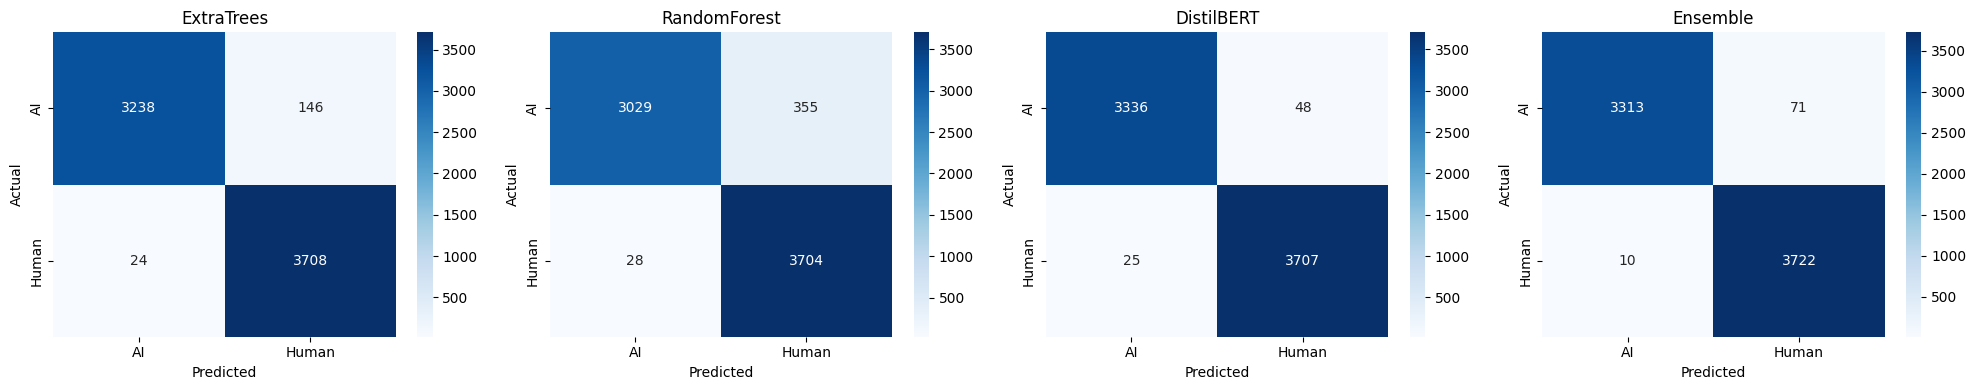

In [ ]:
# Confusion matrices for all models
to_plot = [("ExtraTrees",et_preds),("RandomForest",rf_preds),("Ensemble",ens_preds)]
if bert_trained: to_plot.insert(2,("DistilBERT",bert_preds))

fig, axes = plt.subplots(1, len(to_plot), figsize=(5*len(to_plot), 4))
if len(to_plot) == 1: axes = [axes]
for ax, (name, preds) in zip(axes, to_plot):
    plot_cm(y_test, preds, name, ax)
plt.tight_layout(); plt.show()

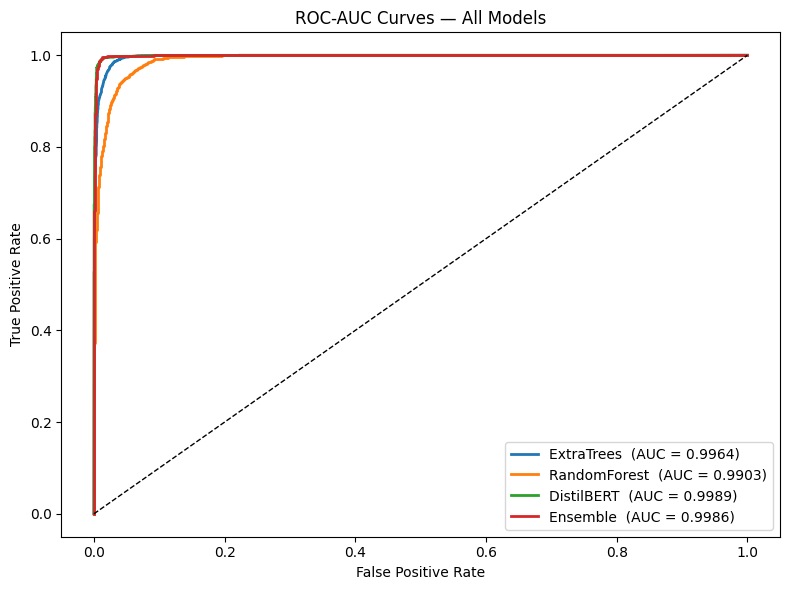

In [ ]:
# ROC-AUC curves — individual models vs. ensemble
fig, ax = plt.subplots(figsize=(8, 6))
curves = [("ExtraTrees",et_proba[:,1]),("RandomForest",rf_proba[:,1]),("Ensemble",ens_proba[:,1])]
if bert_trained: curves.insert(2,("DistilBERT",bert_proba_raw[:,1]))

for name, prob in curves:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-AUC Curves — All Models"); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# Consolidated performance summary table
rows = []
for name, preds, prob in [("ExtraTrees",et_preds,et_proba[:,1]),
                            ("RandomForest",rf_preds,rf_proba[:,1]),
                            ("Ensemble",ens_preds,ens_proba[:,1])]:
    rows.append({"Model":name,
                 "Accuracy":    round(accuracy_score(y_test,preds),4),
                 "F1_Weighted": round(f1_score(y_test,preds,average="weighted"),4),
                 "Precision":   round(precision_score(y_test,preds,average="weighted"),4),
                 "Recall":      round(recall_score(y_test,preds,average="weighted"),4),
                 "ROC_AUC":     round(roc_auc_score(y_test,prob),4)})
if bert_trained:
    rows.insert(2,{"Model":"DistilBERT",
                   "Accuracy":    round(accuracy_score(y_test,bert_preds),4),
                   "F1_Weighted": round(f1_score(y_test,bert_preds,average="weighted"),4),
                   "Precision":   round(precision_score(y_test,bert_preds,average="weighted"),4),
                   "Recall":      round(recall_score(y_test,bert_preds,average="weighted"),4),
                   "ROC_AUC":     round(roc_auc_score(y_test,bert_proba_raw[:,1]),4)})

print(pd.DataFrame(rows).to_string(index=False))

       Model  Accuracy  F1_Weighted  Precision  Recall  ROC_AUC
  ExtraTrees    0.9761       0.9761     0.9766  0.9761   0.9964
RandomForest    0.9462       0.9459     0.9498  0.9462   0.9903
  DistilBERT    0.9897       0.9897     0.9898  0.9897   0.9989
    Ensemble    0.9886       0.9886     0.9888  0.9886   0.9986


In [ ]:
# Quantified evaluation on deliberately casual / humanized AI-style reviews
HUMANISED = [
    ("omg this foundation is literally everything \U0001f62d been using it for 2 weeks nd my skin looks SO good. def repurchasing", 1),
    ("ok so i was skeptical bc the price is kinda high but honestly worth it?? my bf even noticed lol", 1),
    ("arrived in 3 days which was faster than expected tbh. packaging was ok, product itself is decent nothing crazy", 1),
    ("idk why people are hyping this up so much. its fine i guess. does what it says but nothing special", 1),
    ("5 stars obv. use code SAVE10 for discount!! jk lol but seriously this is amazinggg \U0001f4af", 1),
    ("bought this for my mom and she loves it. shipping was fast. would buy again probably", 1),
    ("honestly? mid. expected more based on the reviews. returns were easy tho so cant complain too much", 1),
    ("this thing broke after like 3 uses wtf. not happy. contacted support still waiting to hear back", 1),
    ("AMAZING product. using it everyday now. my skin has literally never looked better in my life no cap", 1),
    ("pretty good for the price i guess. seen better but also seen much worse so yeah 3 stars seems fair", 1),
]

results = []
for rev, true_lbl in HUMANISED:
    cleaned  = remove_stopwords(clean_text(rev))
    tfidf_f  = tfidf.transform([cleaned])
    meta_s   = extract_metadata(rev)
    meta_sc  = scaler.transform(pd.DataFrame([meta_s])[METADATA_FEATURES])
    feat     = hstack([tfidf_f, csr_matrix(meta_sc)])
    et_p = best_et.predict_proba(feat)[0]
    rf_p = best_rf.predict_proba(feat)[0]
    if bert_trained:
        bert_model.eval()
        enc = tokenizer([rev], truncation=True, padding="max_length",
                        max_length=256, return_tensors="pt").to(device)
        with torch.no_grad():
            bp = torch.softmax(bert_model(**enc).logits, dim=1).cpu().numpy()[0]
        fp = W_ET*et_p + W_RF*rf_p + W_BERT*bp
    else:
        bp = np.array([0.5,0.5]); fp = 0.5*et_p + 0.5*rf_p
    pred = int(np.argmax(fp))
    results.append({"Review": rev[:55]+"...","True":"Human",
                    "Predicted":"Human" if pred==1 else "AI",
                    "Human%": f"{fp[1]*100:.1f}","AI%": f"{fp[0]*100:.1f}",
                    "Correct": pred == true_lbl})

h_df = pd.DataFrame(results)
print(f"Humanized Review Accuracy: {h_df['Correct'].mean():.0%}  "
      f"({h_df['Correct'].sum()}/{len(h_df)} correct)\n")
print(h_df[["Review","Predicted","Human%","AI%","Correct"]].to_string(index=False))

Humanized Review Accuracy: 50%  (5/10 correct)

                                                    Review Predicted Human%  AI%  Correct
omg this foundation is literally everything 😭 been usin...        AI   44.9 55.1    False
ok so i was skeptical bc the price is kinda high but ho...        AI   36.3 63.7    False
arrived in 3 days which was faster than expected tbh. p...        AI   24.3 75.7    False
idk why people are hyping this up so much. its fine i g...        AI   17.4 82.6    False
5 stars obv. use code SAVE10 for discount!! jk lol but ...     Human   89.5 10.5     True
bought this for my mom and she loves it. shipping was f...     Human   93.3  6.7     True
honestly? mid. expected more based on the reviews. retu...     Human   57.1 42.9     True
this thing broke after like 3 uses wtf. not happy. cont...        AI   46.9 53.1    False
AMAZING product. using it everyday now. my skin has lit...     Human   89.2 10.8     True
pretty good for the price i guess. seen better but a

In [ ]:
# Save all model artifacts to Google Drive
from google.colab import drive
import shutil

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/My Drive/Colab Notebooks/FYP/ai_review_detector_models"
os.makedirs(DRIVE_PATH, exist_ok=True)

joblib.dump(tfidf,   "tfidf_vectorizer.pkl")
joblib.dump(scaler,  "meta_scaler.pkl")
joblib.dump(best_et, "extra_trees_model.pkl")
joblib.dump(best_rf, "random_forest_model.pkl")

for f in ["tfidf_vectorizer.pkl","meta_scaler.pkl","extra_trees_model.pkl","random_forest_model.pkl"]:
    shutil.copy(f, os.path.join(DRIVE_PATH, f))

if bert_trained:
    torch.save(bert_model.state_dict(), "distilbert_model.pth")
    tokenizer.save_pretrained("distilbert_tokenizer")
    shutil.copy("distilbert_model.pth", os.path.join(DRIVE_PATH, "distilbert_model.pth"))
    dest_tok = os.path.join(DRIVE_PATH, "distilbert_tokenizer")
    if os.path.exists(dest_tok): shutil.rmtree(dest_tok)
    shutil.copytree("distilbert_tokenizer", dest_tok)

    # Save ensemble weights so they can be reloaded exactly
    weights = {"W_ET": W_ET, "W_RF": W_RF, "W_BERT": W_BERT}
    with open(os.path.join(DRIVE_PATH, "ensemble_weights.json"), "w") as f:
        import json; json.dump(weights, f)

print("All artifacts saved to Drive:", DRIVE_PATH)

Mounted at /content/drive
All artifacts saved to Drive: /content/drive/My Drive/Colab Notebooks/FYP/FINAL CODES/ai_review_detector_models


---
## Quick Reload
Run from this cell when reopening the notebook to skip retraining and launch the app directly.

In [2]:
# ── QUICK RELOAD: mount Drive, reinstall deps, load all models ──
import subprocess, sys
subprocess.check_call([sys.executable,"-m","pip","install","-q",
    "textstat","emoji","gdown","nltk==3.8.1","transformers","datasets",
    "scikit-learn","scipy","gradio","imbalanced-learn"])

import os, io, re, json, warnings
import numpy as np, pandas as pd, torch, joblib, nltk, textstat
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")
for r in ["punkt","punkt_tab","stopwords","averaged_perceptron_tagger","averaged_perceptron_tagger_eng"]:
    try: nltk.download(r, quiet=True)
    except: pass

METADATA_FEATURES = ["review_length","burstiness","hedging_ratio","modal_ratio",
                     "adj_density","punct_diversity","flesch_ease","ari_score"]
HEDGING_WORDS = frozenset({"maybe","perhaps","possibly","might","could","seems","appears","likely","unlikely"})
MODAL_VERBS   = frozenset({"would","could","should","might","may","must"})
STOP_WORDS    = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+","",text); text = re.sub(r"\d+","",text)
    text = re.sub(r"[^\w\s]","",text); return re.sub(r"\s+"," ",text).strip()

def remove_stopwords(text):
    return " ".join([w for w in word_tokenize(str(text)) if w not in STOP_WORDS])

def extract_metadata(text):
    if not isinstance(text,str) or not text.strip():
        return pd.Series({f:0.0 for f in METADATA_FEATURES})
    sents=sent_tokenize(text); tokens=word_tokenize(text.lower())
    words=[w for w in tokens if w.isalpha()]; wc=len(words)
    slens=[len(word_tokenize(s)) for s in sents if s.strip()]
    burstiness=float(np.std(slens)) if len(slens)>1 else 0.0
    hedging=sum(1 for w in words if w in HEDGING_WORDS)/(wc+1)
    modal=sum(1 for w in words if w in MODAL_VERBS)/(wc+1)
    tagged=nltk.pos_tag(words) if wc else []
    adj_d=sum(1 for _,t in tagged if t in ("JJ","JJR","JJS"))/(wc+1)
    punct=[c for c in text if c in ".:,!?;:"]
    punct_div=len(set(punct))/(len(punct)+1)
    try: flesch=textstat.flesch_reading_ease(text)
    except: flesch=0.0
    try: ari=textstat.automated_readability_index(text)
    except: ari=0.0
    return pd.Series({"review_length":len(text),"burstiness":burstiness,
                      "hedging_ratio":hedging,"modal_ratio":modal,"adj_density":adj_d,
                      "punct_diversity":punct_div,"flesch_ease":flesch,"ari_score":ari})

from google.colab import drive
if not os.path.exists("/content/drive"): drive.mount("/content/drive")

DRIVE_PATH = "/content/drive/My Drive/Colab Notebooks/FYP/ai_review_detector_models"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tfidf   = joblib.load(os.path.join(DRIVE_PATH,"tfidf_vectorizer.pkl"))
scaler  = joblib.load(os.path.join(DRIVE_PATH,"meta_scaler.pkl"))
best_et = joblib.load(os.path.join(DRIVE_PATH,"extra_trees_model.pkl"))
best_rf = joblib.load(os.path.join(DRIVE_PATH,"random_forest_model.pkl"))

bert_trained=False; tokenizer=None; bert_model=None
bert_path = os.path.join(DRIVE_PATH,"distilbert_model.pth")
tok_path  = os.path.join(DRIVE_PATH,"distilbert_tokenizer")
wt_path   = os.path.join(DRIVE_PATH,"ensemble_weights.json")

if os.path.exists(bert_path) and os.path.exists(tok_path):
    try:
        from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
        tokenizer  = DistilBertTokenizerFast.from_pretrained(tok_path)
        bert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=2)
        bert_model.load_state_dict(torch.load(bert_path,map_location=device))
        bert_model.to(device).eval()
        bert_trained = True
        if os.path.exists(wt_path):
            with open(wt_path) as f: w=json.load(f)
            W_ET=w["W_ET"]; W_RF=w["W_RF"]; W_BERT=w["W_BERT"]
        else:
            W_ET=0.3359; W_RF=0.3230; W_BERT=0.3410
        print(f"All models loaded. Weights — ET:{W_ET:.4f} RF:{W_RF:.4f} BERT:{W_BERT:.4f}")
    except Exception as e:
        print("BERT load failed:", e); W_ET=0.5; W_RF=0.5; W_BERT=0.0
else:
    W_ET=0.5; W_RF=0.5; W_BERT=0.0
    print("ET + RF loaded (no BERT found).")

Mounted at /content/drive


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


All models loaded. Weights — ET:0.3370 RF:0.3165 BERT:0.3465


In [3]:
import gradio as gr

def predict_review(review_text):
    if not review_text or not review_text.strip():
        return "Please enter a review.", "", ""
    cleaned  = remove_stopwords(clean_text(review_text))
    tfidf_f  = tfidf.transform([cleaned])
    meta_s   = extract_metadata(review_text)
    meta_sc  = scaler.transform(pd.DataFrame([meta_s])[METADATA_FEATURES])
    feat     = hstack([tfidf_f, csr_matrix(meta_sc)])
    et_p = best_et.predict_proba(feat)[0]
    rf_p = best_rf.predict_proba(feat)[0]
    if bert_trained:
        bert_model.eval()
        enc = tokenizer([review_text], truncation=True, padding="max_length",
                        max_length=256, return_tensors="pt").to(device)
        with torch.no_grad():
            bp = torch.softmax(bert_model(**enc).logits, dim=1).cpu().numpy()[0]
        fp = W_ET*et_p + W_RF*rf_p + W_BERT*bp
    else:
        bp = np.array([0.5,0.5]); fp = 0.5*et_p + 0.5*rf_p

    ai_pct = fp[0]*100; hu_pct = fp[1]*100
    if   ai_pct >= 75: verdict = f"\u26a0\ufe0f  Likely AI-Generated ({ai_pct:.1f}% AI)"
    elif ai_pct >= 50: verdict = f"\U0001f914 Possibly AI-Generated ({ai_pct:.1f}% AI)"
    elif hu_pct >= 75: verdict = f"\u2705 Likely Human-Written ({hu_pct:.1f}% Human)"
    else:              verdict = f"\u2753 Uncertain  (AI {ai_pct:.1f}% | Human {hu_pct:.1f}%)"

    breakdown = (f"ExtraTrees   :  AI {et_p[0]*100:.1f}%  |  Human {et_p[1]*100:.1f}%\n"
                 f"RandomForest :  AI {rf_p[0]*100:.1f}%  |  Human {rf_p[1]*100:.1f}%\n"
                 f"DistilBERT   :  AI {bp[0]*100:.1f}%  |  Human {bp[1]*100:.1f}%")
    metadata  = (f"Length      : {int(meta_s['review_length'])}\n"
                 f"Flesch Ease : {meta_s['flesch_ease']:.1f}\n"
                 f"ARI Score   : {meta_s['ari_score']:.1f}\n"
                 f"Burstiness  : {meta_s['burstiness']:.3f}\n"
                 f"Hedging     : {meta_s['hedging_ratio']:.4f}\n"
                 f"Adj Density : {meta_s['adj_density']:.3f}")
    return verdict, breakdown, metadata

with gr.Blocks(title="AI Review Detector", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# \U0001f50d AI Review Detector\nPaste any product review to check if it was written by a human or AI.")
    with gr.Row():
        with gr.Column(scale=2):
            inp = gr.Textbox(lines=7, label="Review Text", placeholder="Paste a product review here...")
            btn = gr.Button("Analyse Review", variant="primary")
        with gr.Column(scale=1):
            out_verdict   = gr.Textbox(label="Verdict", lines=2)
            out_breakdown = gr.Textbox(label="Model Breakdown", lines=5)
            out_meta      = gr.Textbox(label="Linguistic Features", lines=8)
    btn.click(fn=predict_review, inputs=inp, outputs=[out_verdict, out_breakdown, out_meta])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9703171d6012534618.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
